In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

from matplotlib import dates

In [2]:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [3]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [4]:
flares = pd.read_csv("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210214_20260228_version1_python.csv")
flarelist = flares.sort_values("25-50 keV", ascending=False).head(500)

In [5]:
df_list=[]
indices=[]
no_file=[]
i=0
for ind in flarelist.index:
    sci_query = Fido.search(a.Time(flarelist['start_UTC'].loc[ind], 
                                   flarelist['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    
    start = parse_time(flarelist['start_UTC'].loc[ind]).datetime
    end = parse_time(flarelist['end_UTC'].loc[ind]).datetime

    gotfile=False
    for n in range(len(sci_query[0])):
        if sci_query[0][n][0].datetime<=t(flarelist['start_UTC'].loc[ind])+dt.timedelta(minutes=5) and sci_query[0][n][1].datetime>=t(flarelist['end_UTC'].loc[ind])-dt.timedelta(minutes=5):
            sci_files = Fido.fetch(sci_query[0][n])
            sci_data = Product(sci_files)
        
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            gotfile=True
            break
            
    if not gotfile:
        no_file.append(i)
        df_list.append(np.nan)
        indices.append(np.nan)
    i+=1

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_L1_stix-sci-xray-spec_20240521T142959-20240521T203500_V04_2405216882-50810.fits:   0%|          | 0.00/1.…

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_L1_stix-sci-xray-spec_20210829T050932-20210829T103844_V04_2108290006-57052.fits:   0%|          | 0.00/31…

IndexError: index 0 is out of bounds for axis 0 with size 0

In [7]:
flag2=[]
iloc=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        bigger=False
        counter=0
        df.index=t(df.index)
        for i in range(len(df['25.0 keV-50.0 keV'])):
            if df['50.0 keV-100.0 keV'].iloc[i]>df['25.0 keV-50.0 keV'].iloc[i]: 
                counter+=1
        if counter>0.25*len(df):
            flag2.append(True)
            bigger=True
        if not bigger:
            flag2.append(False)
    else:
        flag2.append(True)
    iloc+=1

In [8]:
checklist2 = list(np.where(np.array(flag2)==True)[0])

In [9]:
df_list_refined=[]
i=0
for df in df_list:
    if i not in checklist2:
        df_list_refined.append(df)
    i+=1

indices_refined = []
i=0
for ind in indices:
    if i not in checklist2:
        indices_refined.append(ind)
    i+=1

In [10]:
resampled_df_list_peaks = []
i=0
for df in df_list_refined:
    #df = df.truncate(starts[i], starts[i]+dt.timedelta(seconds=max(durations)))
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list_peaks.append(resampled_df)
    i+=1

normalised_df_list_peaks = []
for df in resampled_df_list_peaks:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list_peaks.append(normalised_df)

In [11]:
def flare_durations(list_of_flare_dfs, flare_list_locations):

    durations = []
    estimated_starts = []
    estimated_ends = []
    durations_50100 = []
    estimated_starts_50100 = []
    estimated_ends_50100 = []
    
    for ind, df in enumerate(list_of_flare_dfs):
    
        start = parse_time(flarelist['start_UTC'].loc[flare_list_locations[ind]]).datetime - dt.timedelta(minutes=10)
        end = parse_time(flarelist['end_UTC'].loc[flare_list_locations[ind]]).datetime  + dt.timedelta(minutes=10)
    
        flare_df = df.truncate(start, end)
        flare_df.index = parse_time(flare_df.index).datetime 

        peak = np.max(flare_df['25.0 keV-50.0 keV'])
        peak_loc = flare_df.index[flare_df['25.0 keV-50.0 keV'] == peak][0]
    
        start_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>0.05) & (flare_df.index<peak_loc)]

        found_start=False
        for time in start_df.index:
            start = flare_df.index.get_loc(flare_df.index[flare_df.index == time][0])
            points = flare_df['25.0 keV-50.0 keV'].iloc[start:start+30]
            if points.is_monotonic_increasing:
                estimated_start = time
                found_start=True
                break
        
        if not found_start:
            estimated_start=np.nan

        end_df = flare_df[(flare_df['25.0 keV-50.0 keV']<0.1*peak) & (flare_df.index>peak_loc)]
        if not end_df.empty:
            estimated_end = end_df.index[0]
        else:
            estimated_end = np.nan
    
        estimated_starts.append(estimated_start)
        estimated_ends.append(estimated_end)
        
        if (pd.notna(estimated_start)) & (pd.notna(estimated_end)):
            estimated_duration = (estimated_end - estimated_start).total_seconds()
            durations.append(estimated_duration)
        else:
            durations.append(np.nan)
        
        # flare_df_50100 = flare_df[np.abs(flare_df['50.0 keV-100.0 keV'].diff())>0.02]

        # if not flare_df_50100.empty:
        #     diff_estimated_start_50100 = flare_df_50100.index[0]
        #     diff_estimated_end_50100 = flare_df_50100.index[-1]
    
        #     estimated_starts_50100.append(diff_estimated_start_50100)
        #     estimated_ends_50100.append(diff_estimated_end_50100)
    
        #     estimated_duration_50100 = (diff_estimated_end_50100 - diff_estimated_start_50100).total_seconds()
        #     durations_50100.append(estimated_duration_50100)
    
        # else:
        #     durations_50100.append(np.nan)
        #     estimated_starts_50100.append(np.nan)
        #     estimated_ends_50100.append(np.nan)

    times_25_50 = [estimated_starts, estimated_ends, durations]
    times_50_100 = [estimated_starts_50100, estimated_ends_50100, durations_50100]
            
    return times_25_50, times_50_100

In [12]:
df_list_extrafiltered = []
for df in resampled_df_list_peaks:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 105, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 105, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_extrafiltered.append(df_filtered)

In [13]:
times_25_50, times_50_100 = flare_durations(df_list_extrafiltered, indices_refined)

In [15]:
starts = times_25_50[0]
ends = times_25_50[1]
durations = times_25_50[2]

In [14]:
df_list_filtered = []
for df in resampled_df_list_peaks:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 25, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_filtered.append(df_filtered)

In [22]:
ends[0]

Timestamp('2024-05-14 16:51:23')

In [21]:
df_list_filtered[0]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-05-14 14:30:02,6.575112,1.814218
2024-05-14 14:30:03,6.580510,1.790073
2024-05-14 14:30:04,6.587426,1.768037
2024-05-14 14:30:05,6.595860,1.748110
2024-05-14 14:30:06,6.605811,1.730293
...,...,...
2024-05-14 20:34:55,6.686675,1.944079
2024-05-14 20:34:56,6.707207,1.942107
2024-05-14 20:34:57,6.729460,1.940070
2024-05-14 20:34:58,6.753436,1.937967


In [23]:
flarelist_refined = flarelist.loc[indices_refined]

In [25]:
i=0
firstpeaks = []
for df in df_list_filtered:
    start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
    
    df = df.truncate(start, end)
    peak_counts=np.max(df['25.0 keV-50.0 keV'])
    peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=0.05*peak_counts) #distance=15,
    firstpeaks.append(peaks[0])
    
    # df = df_list_refined[i]
    # df = df.truncate(starts[i], ends[i])
    # fig, ax = plt.subplots()
    # ax.plot(df. index, df['25.0 keV-50.0 keV'])
    # ax.scatter(df.index[peaks], df['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*')
    # fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/peak_testing/flare"+str(i)+".png", bbox_inches='tight')
    
    
    i+=1

# plt.close('all')

In [26]:
timeshifted_df_list_firstpeak = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()

    start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
    
    #
    df = df.truncate(start, end)
    peak_time = df.index[firstpeaks[i]]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-200, 1800)
    timeshifted_df_list_firstpeak.append(timeshifted_df)
    i+=1

firstpeak_list = []
for df in timeshifted_df_list_firstpeak:
    new_index = pd.Index(np.arange(-200, 1800, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    firstpeak_list.append(df)

In [33]:
concat_band1_firstpeak = pd.concat((df['25.0 keV-50.0 keV'] for df in firstpeak_list), axis=1)
averaged_shape_flare_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.mean(axis=1), columns=['25.0 keV-50.0 keV'])
median_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.median(axis=1), columns=['25.0 keV-50.0 keV'])

std_2550_mean_firstpeak = concat_band1_firstpeak.std(axis=1)

upperlim_2550_firstpeak = averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV']+std_2550_mean_firstpeak
lowerlim_2550_firstpeak = averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV']-std_2550_mean_firstpeak

for i in np.arange(0, len(upperlim_2550_firstpeak), 1):
    if lowerlim_2550_firstpeak.iloc[i]<0:
        lowerlim_2550_firstpeak.iloc[i] = 0

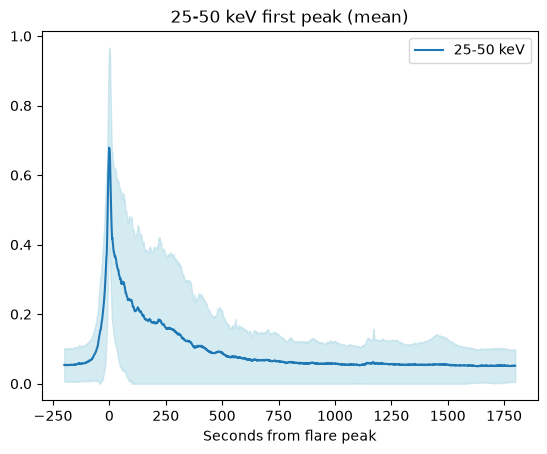

In [36]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550_firstpeak.index, averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(averaged_shape_flare_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('25-50 keV first peak (mean)')
ax.legend()
fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/first_peak_mean.png", bbox_inches='tight')

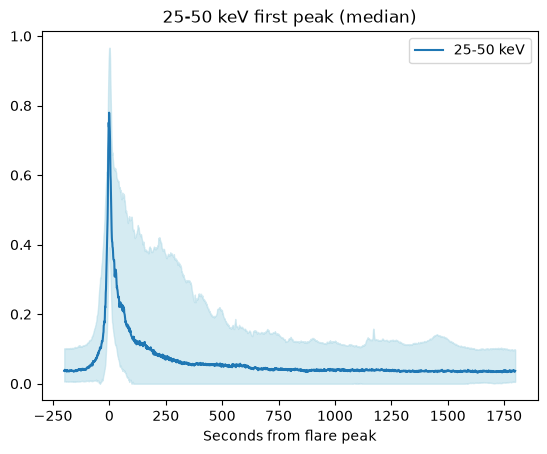

In [37]:
fig, ax = plt.subplots()

ax.plot(median_2550_firstpeak.index, median_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(averaged_shape_flare_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('25-50 keV first peak (median)')
ax.legend()
fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/first_peak_median.png", bbox_inches='tight')